In [26]:
from typing import Annotated,Sequence,TypedDict
from dotenv import load_dotenv
from langchain_core.messages import BaseMessage # This foundational class for all the messages in the langGraph
from langchain_core.messages import ToolMessage # passes back the tool messages back to llm
from langchain_core.messages import SystemMessage # message fro providing instructions to LLM
from langchain_openai import ChatOpenAI
from langchain_core.tools import tool
from langgraph.graph import add_messages
from langgraph.graph import StateGraph,START,END
from langgraph.prebuilt import ToolNode

load_dotenv()

True

In [32]:
class AgentState(TypedDict):
    messages:Annotated[Sequence[BaseMessage],add_messages]

@tool
def add(a:int,b:int):
    """This is an function that help you to add numbers"""
    return a+b

@tool
def multiply(a:int,b:int):
    """This is an function that help you to multiply the numbers"""
    return a*b
@tool
def subtraction(a:int,b:int):
    """This is an function that helos you to subtract the numbers"""
    return a-b

@tool
def divison(a:int,b:int):
    """This is an function that helps you to divide the numbers"""
    return a/b

tools=[add,subtraction,multiply,divison]

model=ChatOpenAI(model="gpt-4o").bind_tools(tools=tools)

def model_call(state:AgentState)->AgentState:
    system_prompt=SystemMessage(
        "You an AI Assistant expert in maths and helps user solve maths questions by using tools provided"
    )
    response=model.invoke([system_prompt] +state["messages"])
    return {"messages":[response]}

def should_continue(state:AgentState):
    message=state["messages"]
    last_message=message[-1]
    if not last_message.tool_calls:
        return "end"
    else:
        return "continue"

graph=StateGraph(AgentState)
graph.add_node("Our_agent",model_call)

tool_node=ToolNode(tools=tools)

graph.add_node("Tools",tool_node)
graph.set_entry_point("Our_agent")

graph.add_conditional_edges(
    "Our_agent",
    should_continue,
    {
        "continue":"Tools",
        "end":END,

    },
    
)
graph.add_edge("Tools","Our_agent")

agent=graph.compile()

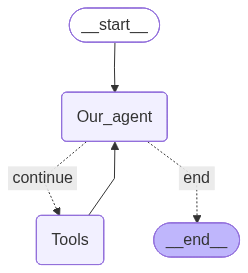

In [29]:
from IPython.display import Image,display
display(Image(agent.get_graph().draw_mermaid_png()))

In [33]:
def print_stream(stream):
    for s in stream:
        message=s["messages"][-1]
        if isinstance(message,tuple):
            print(message)
        else:
            message.pretty_print()

inputs={"messages":[("user","Add 1000+90 and multiply 7 with 7 and divide 5 with 2 and subtract 50-20")]}
print_stream(agent.stream(inputs,stream_mode="values"))


================================ Human Message =================================

Add 1000+90 and multiply 7 with 7 and divide 5 with 2 and subtract 50-20
================================== Ai Message ==================================
Tool Calls:
  add (call_dDGJy6p1Ff9nUIoOhDi27Gwh)
 Call ID: call_dDGJy6p1Ff9nUIoOhDi27Gwh
  Args:
    a: 1000
    b: 90
  multiply (call_Yd7BMmflcaGSWbDKqSf1a9bG)
 Call ID: call_Yd7BMmflcaGSWbDKqSf1a9bG
  Args:
    a: 7
    b: 7
  divison (call_x0d7AtpnDCrqNM8kWnB69vlB)
 Call ID: call_x0d7AtpnDCrqNM8kWnB69vlB
  Args:
    a: 5
    b: 2
  subtraction (call_40MqG7ZCrFZYowqNVwhqsIu8)
 Call ID: call_40MqG7ZCrFZYowqNVwhqsIu8
  Args:
    a: 50
    b: 20
================================= Tool Message =================================
Name: subtraction

30
================================== Ai Message ==================================

Here are the results for each operation:

1. \(1000 + 90 = 1090\)
2. \(7 \times 7 = 49\)
3. \(5 \div 2 = 2.5\)
4. \(50 - 20 = 30